# **Plotting Script: ENSO Phase Duration under Volcanic Forcing**

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
 
# USER SETTINGS
 
RAW_MODELS_CSV  = "/home/563/ft3359/FT-Honours/Honours_Paper/Temporal_Evolution/All_Eruptions/All_eruptions_raw_models.csv"
RAW_RECON_CSV   = "/home/563/ft3359/FT-Honours/Honours_Paper/Temporal_Evolution/All_Eruptions/All_eruptions_raw_recon.csv"
CTRL_MODELS_CSV = "/home/563/ft3359/FT-Honours/Honours_Paper/Temporal_Evolution/All_Eruptions/All_eruptions_control_models.csv"
CTRL_RECON_CSV  = "/home/563/ft3359/FT-Honours/Honours_Paper/Temporal_Evolution/All_Eruptions/All_eruptions_control_recon.csv"
 
# Panel order

PHASE_LEFT   = "Neutral"
PHASES_RIGHT = ["El Niño", "La Niña"]
 
ZOOM_YLIM = None
 
COL_MODELS = "#2166ac"
COL_RECON  = "#d6604d"
COL_BAND_MOD = "#92c5de"
COL_BAND_REC = "#f4a582"
 
X_MOD = 0.0
X_REC = 1.0
JITTER_WIDTH = 0.12
 
SAVE_FIG = True
OUT_PATH = "/home/563/ft3359/FT-Honours/Honours_Paper/Figures/phase_duration_all_eruptions.png"
FIG_DPI  = 300

In [8]:
# LOAD
 
df_raw_mod  = pd.read_csv(RAW_MODELS_CSV)
df_raw_rec  = pd.read_csv(RAW_RECON_CSV)
df_ctrl_mod = pd.read_csv(CTRL_MODELS_CSV)
df_ctrl_rec = pd.read_csv(CTRL_RECON_CSV)
 
ALL_PHASES = [PHASE_LEFT] + PHASES_RIGHT
for df in [df_raw_mod, df_raw_rec, df_ctrl_mod, df_ctrl_rec]:
    df["Phase"] = pd.Categorical(df["Phase"], categories=ALL_PHASES, ordered=True)

In [9]:
# CONTROL STATS — separate for models and reconstructions
 
def ctrl_stats_by_source(df_mod, df_rec, phases):

    stats = {}
    for phase in phases:
        mod_vals = df_mod[df_mod["Phase"] == phase]["remaining_lifetime"].dropna().values
        rec_vals = df_rec[df_rec["Phase"] == phase]["remaining_lifetime"].dropna().values
 
        if mod_vals.size == 0:
            mod_stats = (np.nan, np.nan, np.nan)
        else:
            mod_stats = (
                float(np.median(mod_vals)),
                float(np.percentile(mod_vals, 25)),
                float(np.percentile(mod_vals, 75)),
            )
 
        if rec_vals.size == 0:
            rec_stats = (np.nan, np.nan, np.nan)
        else:
            rec_stats = (
                float(np.median(rec_vals)),
                float(np.percentile(rec_vals, 25)),
                float(np.percentile(rec_vals, 75)),
            )
 
        stats[phase] = mod_stats + rec_stats  # 6-tuple
    return stats
 
ctrl_stats = ctrl_stats_by_source(df_ctrl_mod, df_ctrl_rec, ALL_PHASES)
 
 
# HELPERS
 
rng = np.random.default_rng(42)
 
def jittered_strip(ax, x_centre, values, color, s=18, alpha=0.72, zorder=4):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return
    jitter = rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, size=vals.size)
    ax.scatter(
        x_centre + jitter, vals,
        color=color, s=s, marker="o",
        alpha=alpha, linewidths=0.4, edgecolors="white", zorder=zorder,
    )
 
def pooled_median_bar(ax, x_centre, value, color="black", half_width=0.22, lw=1.2, zorder=5):
    if not np.isfinite(value):
        return
    ax.plot(
        [x_centre - half_width, x_centre + half_width],
        [value, value],
        color=color, lw=lw, solid_capstyle="round", zorder=zorder,
    )
 
def draw_ctrl_band(ax, x_centre, median, q25, q75, color, half_width=0.38, zorder=1):

    if not (np.isfinite(q25) and np.isfinite(q75)):
        return
    ax.fill_betweenx(
        [q25, q75],
        x_centre - half_width,
        x_centre + half_width,
        color=color, alpha=0.25, zorder=zorder,
    )
    if np.isfinite(median):
        ax.plot(
            [x_centre - half_width, x_centre + half_width],
            [median, median],
            color="0.3", lw=1.2, ls="--", alpha=0.8, zorder=zorder + 1,
        )
 
# Panel labels

PANEL_LABELS = {
    "Neutral":  "(a)",
    "El Niño":  "(b)",
    "La Niña":  "(c)",
}
 
def draw_phase(ax, phase, show_ylabel=False):
    mod_med, mod_q25, mod_q75, rec_med, rec_q25, rec_q75 = ctrl_stats[phase]
 
    # Dataset-specific control bands
    
    draw_ctrl_band(ax, X_MOD, mod_med, mod_q25, mod_q75, COL_BAND_MOD)
    draw_ctrl_band(ax, X_REC, rec_med, rec_q25, rec_q75, COL_BAND_REC)
 
    # Raw strips
    
    vals_mod = df_raw_mod[df_raw_mod["Phase"] == phase]["remaining_lifetime"].values
    vals_rec = df_raw_rec[df_raw_rec["Phase"] == phase]["remaining_lifetime"].values
 
    jittered_strip(ax, X_MOD, vals_mod, COL_MODELS)
    jittered_strip(ax, X_REC, vals_rec, COL_RECON)
 
    # Pooled median bars — color-matched to each dataset
    
    pool_med_mod = float(np.median(vals_mod[np.isfinite(vals_mod)])) if vals_mod.size > 0 else np.nan
    pool_med_rec = float(np.median(vals_rec[np.isfinite(vals_rec)])) if vals_rec.size > 0 else np.nan
    pooled_median_bar(ax, X_MOD, pool_med_mod, color=COL_MODELS)
    pooled_median_bar(ax, X_REC, pool_med_rec, color=COL_RECON)
 
    # Panel title with label
    
    label = PANEL_LABELS[phase]
    ax.set_title(f"{label} {phase}", fontsize=12, fontweight="bold", pad=6)
 
    # Cosmetics
    
    ax.set_xticks([X_MOD, X_REC])
    ax.set_xticklabels(["Models", "Recon."], fontsize=12)
    ax.set_xlim(X_MOD - 0.55, X_REC + 0.55)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", length=0, pad=4)
 
    # Faint horizontal grid lines
    
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='0.8', zorder=0)
    ax.set_axisbelow(True)
 
    if show_ylabel:
        ax.set_ylabel("Phase Duration (years)", fontsize=12)
 
    return dict(vals_mod=vals_mod, vals_rec=vals_rec)

Saved: /home/563/ft3359/FT-Honours/Honours_Paper/Figures/phase_duration_all_eruptions.png


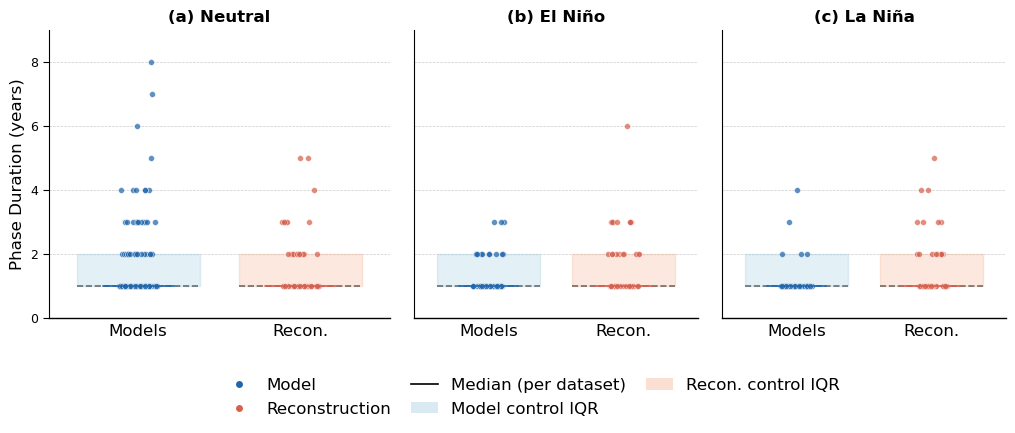

In [10]:
# FIGURE LAYOUT

fig = plt.figure(figsize=(11, 4.5))
gs = gridspec.GridSpec(
    1, 3,
    width_ratios=[1.2, 1, 1],
    wspace=0.08,
    left=0.10, right=0.97,
    top=0.82, bottom=0.18,
)

ax_neutral = fig.add_subplot(gs[0])
ax_elnino  = fig.add_subplot(gs[1], sharey=ax_neutral)
ax_lanina  = fig.add_subplot(gs[2], sharey=ax_neutral)


# DRAW PANELS

annot_neutral = draw_phase(ax_neutral, PHASE_LEFT,      show_ylabel=True)
annot_elnino  = draw_phase(ax_elnino,  PHASES_RIGHT[0], show_ylabel=False)
annot_lanina  = draw_phase(ax_lanina,  PHASES_RIGHT[1], show_ylabel=False)

# Hide y-axis tick labels on shared panels
plt.setp(ax_elnino.get_yticklabels(), visible=False)
plt.setp(ax_lanina.get_yticklabels(), visible=False)
ax_elnino.yaxis.set_tick_params(length=0)
ax_lanina.yaxis.set_tick_params(length=0)
ax_neutral.yaxis.set_tick_params(length=4, direction='out')


# Y-AXIS LIMITS — single shared limit across all panels

all_vals = np.concatenate([
    annot_neutral["vals_mod"][np.isfinite(annot_neutral["vals_mod"])],
    annot_neutral["vals_rec"][np.isfinite(annot_neutral["vals_rec"])],
    annot_elnino["vals_mod"][np.isfinite(annot_elnino["vals_mod"])],
    annot_elnino["vals_rec"][np.isfinite(annot_elnino["vals_rec"])],
    annot_lanina["vals_mod"][np.isfinite(annot_lanina["vals_mod"])],
    annot_lanina["vals_rec"][np.isfinite(annot_lanina["vals_rec"])],
])
y_max = 9
ax_neutral.set_ylim(bottom=0, top=y_max)
ax_neutral.set_yticks(range(0, y_max + 1, 2))

# Solid bottom (x-axis) spine on all panels, matching the y-axis line
for ax in (ax_neutral, ax_elnino, ax_lanina):
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['bottom'].set_color('black')


# LEGEND

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COL_MODELS,
           markersize=6, label="Model"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COL_RECON,
           markersize=6, label="Reconstruction"),
    Line2D([0], [0], color="black", lw=1.2, label="Median (per dataset)"),
    mpatches.Patch(facecolor=COL_BAND_MOD, alpha=0.35, label="Model control IQR"),
    mpatches.Patch(facecolor=COL_BAND_REC, alpha=0.35, label="Recon. control IQR"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.54, 0.08),
    bbox_transform=fig.transFigure,
    columnspacing=1.2,
    handlelength=1.6,
)

# SAVE / SHOW

if SAVE_FIG:
    os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
    fig.savefig(OUT_PATH, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Saved: {OUT_PATH}")

plt.show()